Klasifikácia pomocou MLP

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms.functional as tvf
import torch.nn.functional as tnf
from tqdm import tqdm
from argparse import Namespace
import wandb

Úvodné zobrazenie

In [2]:
filename = "speeddating.csv"
df = pd.read_csv(filename)
pd.set_option('display.max_columns', None)
df.head()





<ipython-input-2-7d8ac704e976>:2: DtypeWarning: Columns (3,10,11,15,16,17,18,19,39,40,41,42,43,44,51,52,53,54,55,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,107,109) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,importance_same_race,importance_same_religion,d_importance_same_race,d_importance_same_religion,field,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,d_pref_o_attractive,d_pref_o_sincere,d_pref_o_intelligence,d_pref_o_funny,d_pref_o_ambitious,d_pref_o_shared_interests,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,d_attractive_o,d_sinsere_o,d_intelligence_o,d_funny_o,d_ambitous_o,d_shared_interests_o,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,d_attractive_important,d_sincere_important,d_intellicence_important,d_funny_important,d_ambtition_important,d_shared_interests_important,attractive,sincere,intelligence,funny,ambition,d_attractive,d_sincere,d_intelligence,d_funny,d_ambition,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,d_attractive_partner,d_sincere_partner,d_intelligence_partner,d_funny_partner,d_ambition_partner,d_shared_interests_partner,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,d_sports,d_tvsports,d_exercise,d_dining,d_museums,d_art,d_hiking,d_gaming,d_clubbing,d_reading,d_tv,d_theater,d_movies,d_concerts,d_music,d_shopping,d_yoga,interests_correlate,d_interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1,female,21,27,6,[4-6],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,2,4,[2-5],[2-5],Law,35,20,20,20,0,5,[21-100],[16-20],[16-20],[16-20],[0-15],[0-15],6,8,8,8,8,6,[6-8],[6-8],[6-8],[6-8],[6-8],[6-8],15,20,20,15,15,15,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6,8,8,8,7,[6-8],[6-8],[6-8],[6-8],[6-8],6,9,7,7,6,5,[6-8],[9-10],[6-8],[6-8],[6-8],[0-5],9,2,8,9,1,1,5,1,5,6,9,1,10,10,9,8,1,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.14,[0-0.33],3,2,4,[0-4],[0-3],[3-5],7,6,[6-8],[5-6],0,1,0,0
1,0,1,female,21,22,1,[0-1],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,2,4,[2-5],[2-5],Law,60,0,0,40,0,0,[21-100],[0-15],[0-15],[21-100],[0-15],[0-15],7,8,10,7,7,5,[6-8],[6-8],[9-10],[6-8],[6-8],[0-5],15,20,20,15,15,15,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6,8,8,8,7,[6-8],[6-8],[6-8],[6-8],[6-8],7,8,7,8,5,6,[6-8],[6-8],[6-8],[6-8],[0-5],[6-8],9,2,8,9,1,1,5,1,5,6,9,1,10,10,9,8,1,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.54,[0.33-1],3,2,4,[0-4],[0-3],[3-5],7,5,[6-8],[5-6],1,1,0,0
2,1,1,female,21,22,1,[0-1],'Asian/Pacific Islander/Asian-American','Asian/Pacific Islander/Asian-American',1,2,4,[2-5],[2-5],Law,19,18,19,18,14,12,[16-20],[16-20],[16-20],[16-20],[0-15],[0-15],10,10,10,10,10,10,[9-10],[9-10],[9-10],[9-10],[9-10],[9-10],15,20,20,15,15,15,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6,8,8,8,7,[6-8],[6-8],[6-8],[6-8],[6-8],5,8,9,8,5,7,[0-5],[6-8],[9-10],[6-8],[0-5],[6-8],9,2,8,9,1,1,5,1,5,6,9,1,10,10,9,8,1,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10],[9-10],[9-10],[6-8],[0-5],0.16,[0-0.33],3,2,4,[0-4],[0-3],[3-5],7,?,[6-8],[0-4],1,1,1,1
3,0,1,female,21,23,2,[2-3],'Asian/Pacific Islander/Asian-American',European/Caucasian-American,0,2,4,[2-5],[2-5],Law,30,5,15,40,5,5,[21-100],[0-15],[0-15],[21-100],[0-15],[0-15],7,8,9,8,9,8,[6-8],[6-8],[9-10],[6-8],[9-10],[6-8],15,20,20,15,15,15,[0-15],[16-20],[16-20],[0-15],[0-15],[0-15],6,8,8,8,7,[6-8],[6-8],[6-8],[6-8],[6-8],7,6,8,7,6,8,[6-8],[6-8],[6-8],[6-8],[6-8],[6-8],9,2,8,9,1,1,5,1,5,6,9,1,10,10,9,8,1,[9-10],[0-5],[6-8],[9-10],[0-5],[0-5],[0-5],[0-5],[0-5],[6-8],[9-10],[0-5],[9-10]

Veľkosť dát (Riadky, stĺpce)

In [3]:
df.shape

(8378, 123)

Odstránenie prázdnych hodnôt typu "?" typom NA pre jednoduchšie spracovanie

In [4]:
df.replace(["?"], pd.NA, inplace=True)
missing_values_per_column = df.isna().sum().sum()
pd.set_option('display.max_rows', None)
print("All missing values ",missing_values_per_column)
#print(df.isna().sum() / len(df) * 100)
# poriešiť nahradenie prázdnych hodnôt
le = LabelEncoder()
objects = 0
for col in df.columns:
  if df[col].dtype == 'object':
      objects += 1
print("Columns of type object: ",objects)

All missing values  18372
Columns of type object:  116


Odstránenie stĺpcov s veľkou mierou chýbania dát


In [5]:
threshold = 0.2  # threshold for missing data
missing_percent = df.isnull().mean()
cols_to_drop = missing_percent[missing_percent > threshold].index
df = df.drop(columns=cols_to_drop)
df.shape

(8378, 122)

Nahradenie chýbajúcich dát

In [6]:
for column in df.columns:
    if df[column].dtype == 'object':  # For categorical columns
        mode_value = df[column].mode()[0]
        df[column].fillna(mode_value, inplace=True)
    else:  # For numerical columns
        median_value = df[column].median()
        df[column].fillna(median_value, inplace=True)
missing_values_per_column = df.isna().sum().sum()
print("Missing values ",missing_values_per_column)


<ipython-input-6-0df75afe9a00>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(median_value, inplace=True)
<ipython-input-6-0df75afe9a00>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

Missing values  0


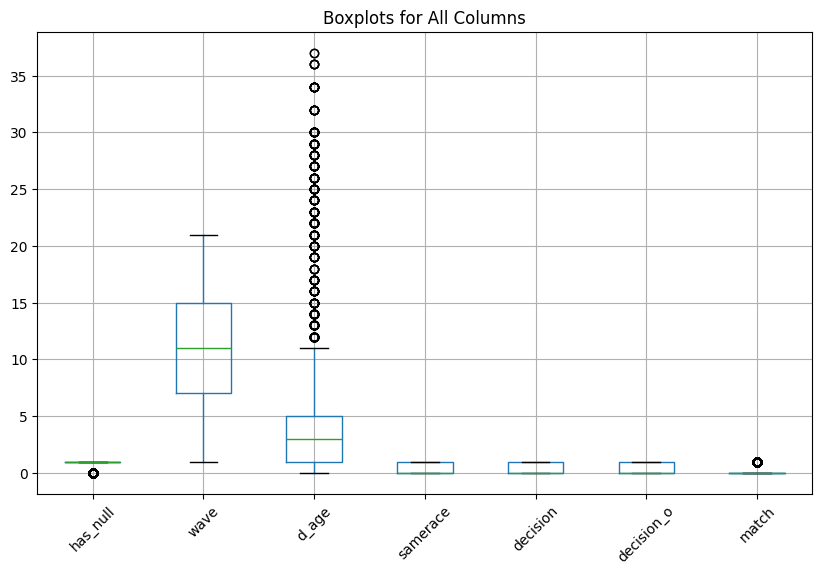

In [7]:
def create_boxplots(df):
    plt.figure(figsize=(10, 6))

    # Boxplots for all numeric columns in the dataframe
    df.boxplot()

    plt.title("Boxplots for All Columns")
    plt.xticks(rotation=45)
    plt.show()

create_boxplots(df)

Úprava pomiešaných dátových typov na jednotný tvar


In [8]:
# Identify columns with mixed types (numbers and strings)
for column in df.columns:
    if df[column].apply(lambda x: isinstance(x, str)).sum() > 0 and df[column].apply(lambda x: isinstance(x, (int, float))).sum() > 0:
        print(f"Column '{column}' contains mixed types (both strings and numbers)")

# Convert columns with mixed types to numeric
for column in df.columns:
    if df[column].dtype == 'object':  # Check if the column is object type
        def convert_to_numeric_or_keep_string(val):
            try:
                return pd.to_numeric(val)  # Try to convert to numeric
            except ValueError:
                return val  # If not convertible, keep it as string

        df[column] = df[column].apply(convert_to_numeric_or_keep_string)  # Apply conversion function
for column in df.columns:
  df[column] = df[column].apply(lambda x: int(x) if isinstance(x, float) and x.is_integer() else x)

# Check how many missing values exist
missing_values_per_column = df.isna().sum().sum()
print("All missing values:", missing_values_per_column)

Column 'age' contains mixed types (both strings and numbers)
Column 'importance_same_race' contains mixed types (both strings and numbers)
Column 'importance_same_religion' contains mixed types (both strings and numbers)
Column 'pref_o_attractive' contains mixed types (both strings and numbers)
Column 'pref_o_sincere' contains mixed types (both strings and numbers)
Column 'pref_o_intelligence' contains mixed types (both strings and numbers)
Column 'pref_o_funny' contains mixed types (both strings and numbers)
Column 'pref_o_ambitious' contains mixed types (both strings and numbers)
Column 'attractive_important' contains mixed types (both strings and numbers)
Column 'sincere_important' contains mixed types (both strings and numbers)
Column 'intellicence_important' contains mixed types (both strings and numbers)
Column 'funny_important' contains mixed types (both strings and numbers)
Column 'ambtition_important' contains mixed types (both strings and numbers)
Column 'shared_interests_imp

Úprava kategorických dát na číselné vyjadrenie

In [9]:
df.head()
print("ok")
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
df.head()

ok


,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,importance_same_race,importance_same_religion,d_importance_same_race,d_importance_same_religion,field,pref_o_attractive,pref_o_sincere,pref_o_intelligence,pref_o_funny,pref_o_ambitious,pref_o_shared_interests,d_pref_o_attractive,d_pref_o_sincere,d_pref_o_intelligence,d_pref_o_funny,d_pref_o_ambitious,d_pref_o_shared_interests,attractive_o,sinsere_o,intelligence_o,funny_o,ambitous_o,shared_interests_o,d_attractive_o,d_sinsere_o,d_intelligence_o,d_funny_o,d_ambitous_o,d_shared_interests_o,attractive_important,sincere_important,intellicence_important,funny_important,ambtition_important,shared_interests_important,d_attractive_important,d_sincere_important,d_intellicence_important,d_funny_important,d_ambtition_important,d_shared_interests_important,attractive,sincere,intelligence,funny,ambition,d_attractive,d_sincere,d_intelligence,d_funny,d_ambition,attractive_partner,sincere_partner,intelligence_partner,funny_partner,ambition_partner,shared_interests_partner,d_attractive_partner,d_sincere_partner,d_intelligence_partner,d_funny_partner,d_ambition_partner,d_shared_interests_partner,sports,tvsports,exercise,dining,museums,art,hiking,gaming,clubbing,reading,tv,theater,movies,concerts,music,shopping,yoga,d_sports,d_tvsports,d_exercise,d_dining,d_museums,d_art,d_hiking,d_gaming,d_clubbing,d_reading,d_tv,d_theater,d_movies,d_concerts,d_music,d_shopping,d_yoga,interests_correlate,d_interests_correlate,expected_happy_with_sd_people,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1,0,21,27,6,2,0,3,0,2,4,1,1,209,35.0,20.0,20.0,20.0,0.0,5.0,2,1,1,1,0,0,6.0,8.0,8.0,8.0,8.0,6.0,1,1,1,1,1,1,15.0,20.0,20.0,15.0,15.0,15.0,0,1,1,0,0,0,6,8,8,8,7,1,1,1,1,1,6.0,9.0,7.0,7.0,6.0,5.0,1,2,1,1,1,0,9,2,8,9,1,1,5,1,5,6,9,1,10,10,9,8,1,2,0,1,2,0,0,0,0,0,1,2,0,2,2,2,1,0,0.14,1,3,4.0,0,0,1,7.0,6.0,1,1,0,1,0,0
1,0,1,0,21,22,1,0,0,3,0,2,4,1,1,209,60.0,0.0,0.0,40.0,0.0,0.0,2,0,0,2,0,0,7.0,8.0,10.0,7.0,7.0,5.0,1,1,2,1,1,0,15.0,20.0,20.0,15.0,15.0,15.0,0,1,1,0,0,0,6,8,8,8,7,1,1,1,1,1,7.0,8.0,7.0,8.0,5.0,6.0,1,1,1,1,0,1,9,2,8,9,1,1,5,1,5,6,9,1,10,10,9,8,1,2,0,1,2,0,0,0,0,0,1,2,0,2,2,2,1,0,0.54,2,3,4.0,0,0,1,7.0,5.0,1,1,1,1,0,0
2,1,1,0,21,22,1,0,0,0,1,2,4,1,1,209,19.0,18.0,19.0,18.0,14.0,12.0,1,1,1,1,0,0,10.0,10.0,10.0,10.0,10.0,10.0,2,2,2,2,2,2,15.0,20.0,20.0,15.0,15.0,15.0,0,1,1,0,0,0,6,8,8,8,7,1,1,1,1,1,5.0,8.0,9.0,8.0,5.0,7.0,0,1,2,1,0,1,9,2,8,9,1,1,5,1,5,6,9,1,10,10,9,8,1,2,0,1,2,0,0,0,0,0,1,2,0,2,2,2,1,0,0.16,1,3,4.0,0,0,1,7.0,5.0,1,0,1,1,1,1
3,0,1,0,21,23,2,1,0,3,0,2,4,1,1,209,30.0,5.0,15.0,40.0,5.0,5.0,2,0,0,2,0,0,7.0,8.0,9.0,8.0,9.0,8.0,1,1,2,1,2,1,15.0,20.0,20.0,15.0,15.0,15.0,0,1,1,0,0,0,6,8,8,8,7,1,1,1,1,1,7.0,6.0,8.0,7.0,6.0,8.0,1,1,1,1,1,1,9,2,8,9,1,1,5,1,5,6,9,1,10,10,9,8,1,2,0,1,2,0,0,0,0,0,1,2,0,2,2,2,1,0,0.61,2,3,4.0,0,0,1,7.0,6.0,1,1,0,1,1,1
4,0,1,0,21,24,3,1,0,2,0,2,4,1,1,209,30.0,10.0,20.0,10.0,10.0,20.0,2,0,1,0,0,1,8.0,7.0,9.0,6.0,9.0,7.0,1,1,2,1,2,1,15.0,20.0,20.0,15.0,15.0,15.0,0,1,1,0,0,0,6,8,8,8,7,1,1,1,1,1,5.0,6.0,7.0,7.0,6.0,6.0,0,1,1,1,1,1,9,2,8,9,1,1,5,1,5,6,9,1,10,10,9,8,1,2,0,1,2,0,0,0,0,0,1,2,0,2,2,2,1,0,0.21,1,3,4.0,0,0,1,6.0,6.0,1,1,0,1,1,1


Zobrazenie rozdelenia dát

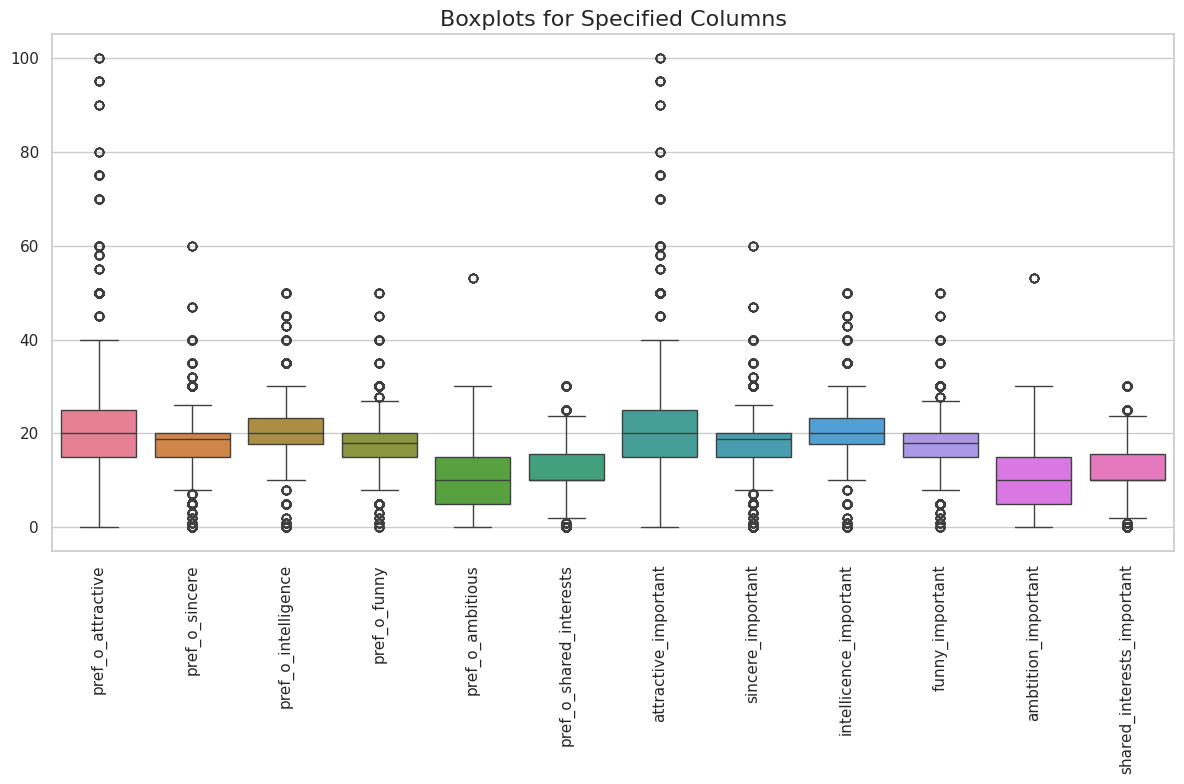

In [10]:
columns = [
    'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny',
    'pref_o_ambitious', 'pref_o_shared_interests', 'attractive_important',
    'sincere_important', 'intellicence_important', 'funny_important',
    'ambtition_important', 'shared_interests_important'
]

# Create a subset of the DataFrame with the specified columns
df_subset = df[columns]

sns.set(style="whitegrid")

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_subset)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)

plt.title('Boxplots for Specified Columns', fontsize=16)

plt.tight_layout()
plt.show()

Spracovanie outlierov-odstránenie na základe kvantilov

In [11]:
columns_to_filter = [
    'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious',
    'pref_o_shared_interests', 'attractive_important', 'sincere_important', 'intellicence_important',
    'funny_important', 'ambtition_important', 'shared_interests_important'
]

lower_1st = df[columns_to_filter].quantile(0.01)
upper_99th = df[columns_to_filter].quantile(0.99)

outlier_mask = (df[columns_to_filter] < lower_1st) | (df[columns_to_filter] > upper_99th)

outliers_count = outlier_mask.sum()

print("Outliers removed per column:")
print(outliers_count)

df_filtered = df[~outlier_mask.any(axis=1)]

rows_removed = df.shape[0] - df_filtered.shape[0]
print(f"Total rows removed: {rows_removed}")

df_filtered = df_filtered.dropna(subset=columns_to_filter)

print(f"Final dataset size: {df_filtered.shape[0]} rows")

Outliers removed per column:
pref_o_attractive             114
pref_o_sincere                 23
pref_o_intelligence           162
pref_o_funny                  147
pref_o_ambitious               65
pref_o_shared_interests         0
attractive_important           77
sincere_important              23
intellicence_important        162
funny_important               147
ambtition_important            65
shared_interests_important      0
dtype: int64
Total rows removed: 738
Final dataset size: 7640 rows


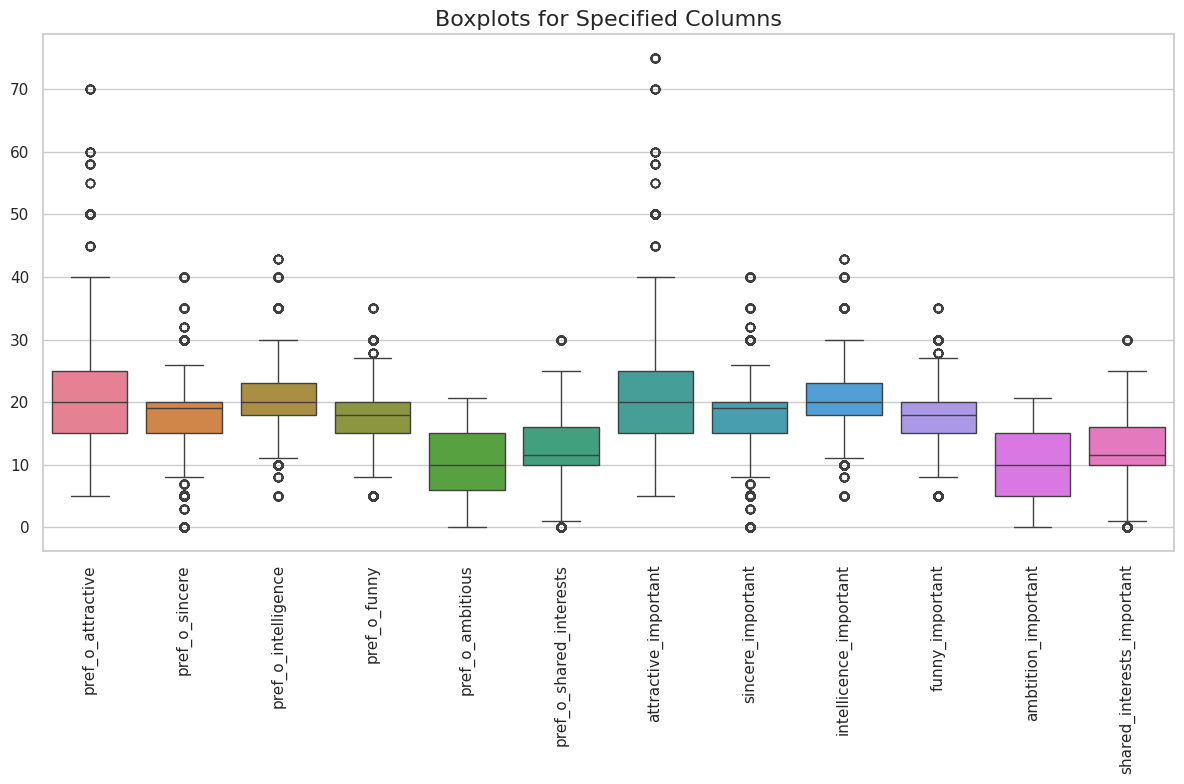

In [12]:
columns = [
    'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny',
    'pref_o_ambitious', 'pref_o_shared_interests', 'attractive_important',
    'sincere_important', 'intellicence_important', 'funny_important',
    'ambtition_important', 'shared_interests_important'
]

# Create a subset of the DataFrame with the specified columns
df_subset = df_filtered[columns]

# Set the plot style
sns.set(style="whitegrid")

# Create the boxplots
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_subset)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=90)

# Add a title
plt.title('Boxplots for Specified Columns', fontsize=16)

# Display the plot
plt.tight_layout()
plt.show()

In [13]:
df_filtered.shape

(7640, 122)

Vybrali sme quantile 20 a 80 z dôvodu že upravené dáta su viac ako v polovičnom množstve oproti 25/75 z dôvodu aby sme nerobily príliš veľké zmeny v dátach, ktoré môžu byť nežiadúce


In [14]:
def clip_outliers(df_l, columns):
    # Create a copy of the DataFrame to avoid modifying the original
    df_copy = df_l.copy()

    Q1 = df_copy[columns].quantile(0.20)
    Q3 = df_copy[columns].quantile(0.8)
    IQR = Q3 - Q1

    total_clipped = 0

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify lower and upper outliers
    lower_outliers = df_copy[columns] < lower_bound
    upper_outliers = df_copy[columns] > upper_bound

    # Print outlier details for each column
    print("Clipped values per column:")
    for col in columns:
        lower_count = lower_outliers[col].sum()
        upper_count = upper_outliers[col].sum()
        total_count = lower_count + upper_count
        total_clipped += total_count  # Add to the total clipped counter
        print(f"{col}: {total_count} values clipped (Lower: {lower_count}, Upper: {upper_count})")

    print(f"\nTotal clipped values across all columns: {total_clipped}")

    # Clip the values in the copy
    df_copy[columns] = df_copy[columns].clip(lower=lower_bound, upper=upper_bound, axis=1)

    return df_copy


# List of selected columns
selected_columns = [
    'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious',
    'pref_o_shared_interests', 'attractive_important', 'sincere_important', 'intellicence_important',
    'funny_important', 'ambtition_important', 'shared_interests_important'
]
# Apply clipping and print results
df_clipped = clip_outliers(df_filtered, selected_columns)

Clipped values per column:
pref_o_attractive: 332 values clipped (Lower: 0, Upper: 332)
pref_o_sincere: 607 values clipped (Lower: 168, Upper: 439)
pref_o_intelligence: 75 values clipped (Lower: 0, Upper: 75)
pref_o_funny: 305 values clipped (Lower: 0, Upper: 305)
pref_o_ambitious: 0 values clipped (Lower: 0, Upper: 0)
pref_o_shared_interests: 0 values clipped (Lower: 0, Upper: 0)
attractive_important: 369 values clipped (Lower: 0, Upper: 369)
sincere_important: 605 values clipped (Lower: 167, Upper: 438)
intellicence_important: 75 values clipped (Lower: 0, Upper: 75)
funny_important: 303 values clipped (Lower: 0, Upper: 303)
ambtition_important: 0 values clipped (Lower: 0, Upper: 0)
shared_interests_important: 0 values clipped (Lower: 0, Upper: 0)

Total clipped values across all columns: 2671


In [15]:
df_clipped.shape

(7640, 122)

Zobrazenie korelácie medzi atribútami

In [16]:
column_name = "match"
correlations_sorted = df_clipped.corr()[column_name].sort_values(ascending=False)

print(correlations_sorted)

match                              1.000000
decision                           0.518605
decision_o                         0.518605
like                               0.294567
d_like                             0.282628
funny_o                            0.270611
funny_partner                      0.270051
d_funny_o                          0.264808
d_funny_partner                    0.264761
shared_interests_partner           0.263721
shared_interests_o                 0.262942
guess_prob_liked                   0.255398
attractive_partner                 0.254483
attractive_o                       0.254182
d_shared_interests_partner         0.253427
d_shared_interests_o               0.252688
d_guess_prob_liked                 0.249037
d_attractive_o                     0.234451
d_attractive_partner               0.234199
d_intelligence_o                   0.160019
d_intelligence_partner             0.159121
intelligence_o                     0.159000
intelligence_partner            

MLP Model

In [17]:
class Statistics:
  def __init__(self):
    self.values = dict()       # dvojice k -> sum, count

  def step(self, key, value):
    sum, count  = 0.0, 0.0
    if key in self.values:
      sum, count = self.values[key]
    sum += value
    count += 1.0
    self.values[key] = (sum, count)

  def get(self):
    result = dict()
    for k, (sum,count) in self.values.items():
      result[k] = float(sum/count)
    return result

  @staticmethod
  def merge(s1,s2):
    result = s1.get()
    result.update(s2.get())
    return result


Výber atribútov

In [18]:
correlation_threshold = 0.2  # Adjust this threshold
selected_features = df_clipped.corr()["match"].abs().sort_values(ascending=False)
selected_features = selected_features[selected_features > correlation_threshold].index.tolist()
selected_features.remove("match")  # Remove target column

print("Selected features:", selected_features)
print(f"Number of selected features: {len(selected_features)}")
df_clipped = df_clipped[selected_features + ["match"]]  # Keep only relevant columns

Selected features: ['decision', 'decision_o', 'like', 'd_like', 'funny_o', 'funny_partner', 'd_funny_o', 'd_funny_partner', 'shared_interests_partner', 'shared_interests_o', 'guess_prob_liked', 'attractive_partner', 'attractive_o', 'd_shared_interests_partner', 'd_shared_interests_o', 'd_guess_prob_liked', 'd_attractive_o', 'd_attractive_partner']
Number of selected features: 18


In [19]:
# in this part we can ignore columns with 2high correlation
correlation_threshold_peak = 0.3
correlation_threshold = 0.25  # Adjust this threshold
selected_features = df_clipped.corr()["match"].abs().sort_values(ascending=False)
selected_features = selected_features[selected_features > correlation_threshold]
selected_features = selected_features[selected_features < correlation_threshold_peak].index.tolist()

if "match" in selected_features:
    selected_features.remove("match")

print("Selected features:", selected_features)
print(f"Number of selected features: {len(selected_features)}")
df_clipped = df_clipped[selected_features + ["match"]]  # Keep only relevant columns

Selected features: ['like', 'd_like', 'funny_o', 'funny_partner', 'd_funny_o', 'd_funny_partner', 'shared_interests_partner', 'shared_interests_o', 'guess_prob_liked', 'attractive_partner', 'attractive_o', 'd_shared_interests_partner', 'd_shared_interests_o']
Number of selected features: 13


Príprava dát na trénovanie a testovanie

In [20]:
df = df_clipped.copy()
# Select features and target
FEATURES = selected_features  # Replace with your selected features
TARGET = "match"

X = df[FEATURES].values  # Convert features to numpy
y = df[TARGET].values     # Target variable

# Split data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize (important for neural networks!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)  # Classification = LongTensor
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

In [21]:
df.shape


(7640, 14)

In [22]:
from torch.utils.data import Dataset, DataLoader

class SpeedDatingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class DataModule:
    def __init__(self, cfg, X_train, y_train, X_val, y_val):
        self.cfg = cfg

        self.dataset_train = SpeedDatingDataset(X_train, y_train)
        self.dataset_val = SpeedDatingDataset(X_val, y_val)

    def setup(self):
        self.dataloader_train = DataLoader(self.dataset_train, batch_size=self.cfg.batch_size, shuffle=True)
        self.dataloader_val = DataLoader(self.dataset_val, batch_size=self.cfg.batch_size, shuffle=False)

In [23]:
import torch.nn as nn

class MultilayerPerceptron(nn.Module):
    def __init__(self,drop_rate, nin, nhidden, nout):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(nin, nhidden)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(drop_rate)  # Dropout with 30% neurons randomly disabled
        self.fc2 = nn.Linear(nhidden, nout)


    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        if self.training:  # Dropout is applied only during training
            x = self.dropout(x)
        x = self.fc2(x)
        return x

In [24]:
def on_epoch_complete(epoch,stats):
  wandb.log({"epoch" : epoch, **stats})

In [25]:
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

class Trainer:
    def __init__(self, cfg, model):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.cfg = cfg
        self.model = model.to(self.device)

        self.opt = optim.Adam(self.model.parameters(), lr=cfg.learning_rate)
        self.loss_fn = nn.CrossEntropyLoss()  # Classification loss
        self.best_val_acc = 0.0  # To track best validation accuracy
        self.patience = 5  # Number of epochs with no improvement before stopping (for overfitting)
        self.no_improvement_count = 0  # Counter to track the number of epochs without improvement

    def setup(self, datamodule):
        self.datamodule = datamodule
        self.datamodule.setup()

    def compute_accuracy(self, y_hat, y):
        predictions = torch.argmax(y_hat, dim=1)  # Get class with highest score
        return (predictions == y).float().mean().item()

    def fit(self):
        for epoch in range(self.cfg.max_epochs):
            self.model.train()
            stats = {"loss_train": 0.0, "acc_train": 0.0}
            num_batches = len(self.datamodule.dataloader_train)  # Total training batches

            # Training loop
            with tqdm(self.datamodule.dataloader_train, desc=f"Train Epoch {epoch+1}") as progress:
                for x, y in progress:
                    x, y = x.to(self.device), y.to(self.device)

                    # Forward pass
                    y_hat = self.model(x)
                    loss = self.loss_fn(y_hat, y)

                    # Backward pass
                    self.opt.zero_grad()
                    loss.backward()
                    self.opt.step()

                    # Update statistics
                    stats["loss_train"] += loss.item() / num_batches  # Average loss
                    stats["acc_train"] += self.compute_accuracy(y_hat, y) / num_batches  # Average accuracy
                    progress.set_postfix(stats)

            wandb.log(stats)

            # Validation Phase
            self.model.eval()
            stats_val = {"loss_val": 0.0, "acc_val": 0.0}
            num_batches = len(self.datamodule.dataloader_val)  # Total validation batches

            with torch.no_grad():
                with tqdm(self.datamodule.dataloader_val, desc=f"Val Epoch {epoch+1}") as progress:
                    for x, y in progress:
                        x, y = x.to(self.device), y.to(self.device)

                        # Forward pass
                        y_hat = self.model(x)
                        loss = self.loss_fn(y_hat, y)

                        # Update statistics
                        stats_val["loss_val"] += loss.item() / num_batches  # Average loss
                        stats_val["acc_val"] += self.compute_accuracy(y_hat, y) / num_batches  # Average accuracy
                        progress.set_postfix(stats_val)

            # Early stopping criteria: Stop if validation accuracy reaches 100% or if overfitting is detected
            val_acc = stats_val["acc_val"]
            print(f"Epoch {epoch+1}, Validation Accuracy: {val_acc:.4f}")

            wandb.log(stats_val)

            #This part of code is temporary comented so we can train on fixed number of epochs
            """
            if val_acc == 1.0:
                print("100% Validation Accuracy reached. Stopping training.")
                break  # Stop if 100% accuracy is reached

            # Track best validation accuracy and check for overfitting
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.no_improvement_count = 0  # Reset counter if there's an improvement
            else:
                self.no_improvement_count += 1

            if self.no_improvement_count >= self.patience:
                print(f"Overfitting detected. Stopping training after {self.patience} epochs without improvement.")
                break  # Stop training if validation accuracy hasn't improved for `patience` epochs
          """


In [26]:
wandb.init()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: farminmansk (farminmansk-fiit-stu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [27]:
from argparse import Namespace

# Define hyperparameters
cfg = Namespace(
    batch_size=24,
    num_workers=2,
    max_epochs=10,
    learning_rate=0.005,
    num_hidden=128,
    droping = 0.3
)

# Initialize model
model = MultilayerPerceptron(
    drop_rate = cfg.droping,
    nin=len(FEATURES),  # Number of input features
    nhidden=cfg.num_hidden,
    nout=2  # Binary classification (match or no match)
)


run = wandb.init(project="NS_Testing", name="Best", config=cfg)

# Create DataModule
datamodule = DataModule(cfg, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor)

# Train model
trainer = Trainer(cfg, model)
trainer.setup(datamodule)
trainer.fit()
run = wandb.finish()

Val Epoch 1: 100%|██████████| 64/64 [00:00<00:00, 385.82it/s, loss_val=0.336, acc_val=0.853]


Epoch 1, Validation Accuracy: 0.8525


Val Epoch 2: 100%|██████████| 64/64 [00:00<00:00, 391.84it/s, loss_val=0.333, acc_val=0.857]


Epoch 2, Validation Accuracy: 0.8571


Val Epoch 3: 100%|██████████| 64/64 [00:00<00:00, 413.46it/s, loss_val=0.328, acc_val=0.862]


...

Val Epoch 9: 100%|██████████| 64/64 [00:00<00:00, 389.91it/s, loss_val=0.33, acc_val=0.853]


Epoch 9, Validation Accuracy: 0.8529


Val Epoch 10: 100%|██████████| 64/64 [00:00<00:00, 413.06it/s, loss_val=0.33, acc_val=0.85]


Epoch 10, Validation Accuracy: 0.8503


acc_train,▁▅▅▇▆▅▅█▇█
acc_val,▅▆█▃▁▂▄█▅▄
loss_train,█▅▄▃▂▃▂▁▁▂
loss_val,▇▅▁█▇▃▃▁▃▂
acc_train,0.86119
acc_val,0.85026
loss_train,0.32345
loss_val,0.32971


In [28]:
def train_model(batch_size=16, num_workers=2, max_epochs=10, learning_rate=0.1, num_hidden=128, drop_rate=0.2, project_name="NS_Testing", run_name="example"):

    cfg = Namespace(
        batch_size=batch_size,
        num_workers=num_workers,
        max_epochs=max_epochs,
        learning_rate=learning_rate,
        num_hidden=num_hidden,
        drop_rate=drop_rate
    )


    model = MultilayerPerceptron(
        drop_rate=cfg.drop_rate,
        nin=len(FEATURES),
        nhidden=cfg.num_hidden,
        nout=2
    )


    run = wandb.init(project=project_name, name=run_name, config=vars(cfg))


    datamodule = DataModule(cfg, X_train_tensor, y_train_tensor, X_val_tensor, y_val_tensor)


    trainer = Trainer(cfg, model)
    trainer.setup(datamodule)
    trainer.fit()


    wandb.finish()




Testovanie s rôzne nastavenými parametrami

In [29]:
# First 12
train_model(batch_size=16, learning_rate=0.1, num_hidden=128, drop_rate=0.3, run_name="B1N1L1D1")
train_model(batch_size=16, learning_rate=0.1, num_hidden=128, drop_rate=0.2, run_name="B1N1L1D2")
train_model(batch_size=16, learning_rate=0.01, num_hidden=128, drop_rate=0.3, run_name="B1N1L2D1")
train_model(batch_size=16, learning_rate=0.01, num_hidden=128, drop_rate=0.2, run_name="B1N1L2D2")
train_model(batch_size=16, learning_rate=0.005, num_hidden=128, drop_rate=0.3, run_name="B1N1L3D1")
train_model(batch_size=16, learning_rate=0.005, num_hidden=128, drop_rate=0.2, run_name="B1N1L3D2")
train_model(batch_size=16, learning_rate=0.1, num_hidden=256, drop_rate=0.3, run_name="B1N2L1D1")
train_model(batch_size=16, learning_rate=0.1, num_hidden=256, drop_rate=0.2, run_name="B1N2L1D2")
train_model(batch_size=16, learning_rate=0.01, num_hidden=256, drop_rate=0.3, run_name="B1N2L2D1")
train_model(batch_size=16, learning_rate=0.01, num_hidden=256, drop_rate=0.2, run_name="B1N2L2D2")
train_model(batch_size=16, learning_rate=0.005, num_hidden=256, drop_rate=0.3, run_name="B1N2L3D1")
train_model(batch_size=16, learning_rate=0.005, num_hidden=256, drop_rate=0.2, run_name="B1N2L3D2")

Val Epoch 1: 100%|██████████| 96/96 [00:00<00:00, 433.24it/s, loss_val=0.565, acc_val=0.824]


Epoch 1, Validation Accuracy: 0.8242


Val Epoch 2: 100%|██████████| 96/96 [00:00<00:00, 194.23it/s, loss_val=1.05, acc_val=0.712]


Epoch 2, Validation Accuracy: 0.7116


Val Epoch 3: 100%|██████████| 96/96 [00:00<00:00, 184.70it/s, loss_val=0.532, acc_val=0.831]


...

Val Epoch 9: 100%|██████████| 96/96 [00:00<00:00, 375.55it/s, loss_val=0.332, acc_val=0.852]


Epoch 9, Validation Accuracy: 0.8522


Val Epoch 10: 100%|██████████| 96/96 [00:00<00:00, 478.85it/s, loss_val=0.34, acc_val=0.852]


Epoch 10, Validation Accuracy: 0.8516


acc_train,▁▆▅▇▆▇█▅██
acc_val,▄█▅▅▆▅▁▃▅▅
loss_train,█▅▅▄▃▃▂▂▂▁
loss_val,█▂▂▄▂▂▆▅▁▃
acc_train,0.85831
acc_val,0.85156
loss_train,0.32133
loss_val,0.33954


In [30]:
# second 12
train_model(batch_size=24, learning_rate=0.1, num_hidden=128, drop_rate=0.3, run_name="B2N1L1D1")
train_model(batch_size=24, learning_rate=0.1, num_hidden=128, drop_rate=0.2, run_name="B2N1L1D2")
train_model(batch_size=24, learning_rate=0.01, num_hidden=128, drop_rate=0.3, run_name="B2N1L2D1")
train_model(batch_size=24, learning_rate=0.01, num_hidden=128, drop_rate=0.2, run_name="B2N1L2D2")
train_model(batch_size=24, learning_rate=0.005, num_hidden=128, drop_rate=0.3, run_name="B2N1L3D1")
train_model(batch_size=24, learning_rate=0.005, num_hidden=128, drop_rate=0.2, run_name="B2N1L3D2")
train_model(batch_size=24, learning_rate=0.1, num_hidden=256, drop_rate=0.3, run_name="B2N2L1D1")
train_model(batch_size=24, learning_rate=0.1, num_hidden=256, drop_rate=0.2, run_name="B2N2L1D2")
train_model(batch_size=24, learning_rate=0.01, num_hidden=256, drop_rate=0.3, run_name="B2N2L2D1")
train_model(batch_size=24, learning_rate=0.01, num_hidden=256, drop_rate=0.2, run_name="B2N2L2D2")
train_model(batch_size=24, learning_rate=0.005, num_hidden=256, drop_rate=0.3, run_name="B2N2L3D1")
train_model(batch_size=24, learning_rate=0.005, num_hidden=256, drop_rate=0.2, run_name="B2N2L3D2")

Val Epoch 1: 100%|██████████| 64/64 [00:00<00:00, 379.49it/s, loss_val=0.512, acc_val=0.831]


Epoch 1, Validation Accuracy: 0.8311


Val Epoch 2: 100%|██████████| 64/64 [00:00<00:00, 395.28it/s, loss_val=0.45, acc_val=0.828]


Epoch 2, Validation Accuracy: 0.8285


Val Epoch 3: 100%|██████████| 64/64 [00:00<00:00, 436.97it/s, loss_val=0.497, acc_val=0.832]


...

Val Epoch 9: 100%|██████████| 64/64 [00:00<00:00, 287.18it/s, loss_val=0.342, acc_val=0.85]


Epoch 9, Validation Accuracy: 0.8499


Val Epoch 10: 100%|██████████| 64/64 [00:00<00:00, 399.43it/s, loss_val=0.33, acc_val=0.858]


Epoch 10, Validation Accuracy: 0.8577


acc_train,▁▇▆█▆▄▇▆▆▇
acc_val,█▆▇▆▅▁▅▆▅█
loss_train,█▄▄▃▃▃▂▂▂▁
loss_val,▇▅▃▃▄█▂▃▆▁
acc_train,0.86111
acc_val,0.85775
loss_train,0.31876
loss_val,0.33019


In [31]:
# last 12
train_model(batch_size=32, learning_rate=0.1, num_hidden=128, drop_rate=0.3, run_name="B3N1L1D1")
train_model(batch_size=32, learning_rate=0.1, num_hidden=128, drop_rate=0.2, run_name="B3N1L1D2")
train_model(batch_size=32, learning_rate=0.01, num_hidden=128, drop_rate=0.3, run_name="B3N1L2D1")
train_model(batch_size=32, learning_rate=0.01, num_hidden=128, drop_rate=0.2, run_name="B3N1L2D2")
train_model(batch_size=32, learning_rate=0.005, num_hidden=128, drop_rate=0.3, run_name="B3N1L3D1")
train_model(batch_size=32, learning_rate=0.005, num_hidden=128, drop_rate=0.2, run_name="B3N1L3D2")
train_model(batch_size=32, learning_rate=0.1, num_hidden=256, drop_rate=0.3, run_name="B3N2L1D1")
train_model(batch_size=32, learning_rate=0.1, num_hidden=256, drop_rate=0.2, run_name="B3N2L1D2")
train_model(batch_size=32, learning_rate=0.01, num_hidden=256, drop_rate=0.3, run_name="B3N2L2D1")
train_model(batch_size=32, learning_rate=0.01, num_hidden=256, drop_rate=0.2, run_name="B3N2L2D2")
train_model(batch_size=32, learning_rate=0.005, num_hidden=256, drop_rate=0.3, run_name="B3N2L3D1")
train_model(batch_size=32, learning_rate=0.005, num_hidden=256, drop_rate=0.2, run_name="B3N2L3D2")

Val Epoch 1: 100%|██████████| 48/48 [00:00<00:00, 409.43it/s, loss_val=0.46, acc_val=0.827]


Epoch 1, Validation Accuracy: 0.8268


Val Epoch 2: 100%|██████████| 48/48 [00:00<00:00, 370.52it/s, loss_val=0.447, acc_val=0.832]


Epoch 2, Validation Accuracy: 0.8320


Val Epoch 3: 100%|██████████| 48/48 [00:00<00:00, 442.56it/s, loss_val=0.63, acc_val=0.827]


...

Val Epoch 9: 100%|██████████| 48/48 [00:00<00:00, 413.09it/s, loss_val=0.331, acc_val=0.851]


Epoch 9, Validation Accuracy: 0.8511


Val Epoch 10: 100%|██████████| 48/48 [00:00<00:00, 431.47it/s, loss_val=0.365, acc_val=0.845]

Epoch 10, Validation Accuracy: 0.8448


acc_train,▁▇▇█▇▇▇▇█▇
acc_val,█▃▅▅▂█▅▃▄▁
loss_train,█▄▃▃▂▂▂▁▁▂
loss_val,▁▃▃▂▂▁▂▃▁█
acc_train,0.85864
acc_val,0.84484
loss_train,0.32165
loss_val,0.36513
